In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 02 — Closeness, metrics, neighborhoods, and topologies

Read `lessons/02_lesson.md` first. Predict each result before execution. This is a fully worked lab; independent exercises and solutions are separate. All real examples before Stage 12 restrict digit displays to training data.

## Setup
This cell locates the project, loads standard numerical tools, and creates only this stage’s output folder. The mathematical work begins below.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/manifest.json").exists() and (p / "src/shape_lab").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the extracted listening_to_shape_lab folder.")
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.display import show_and_save, save_json
OUT = ROOT / "reports/stage_02"
OUT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT.relative_to(ROOT))

Output folder: reports/stage_02


## Exact metric counterexample and finite topology
A finite exhaustive check is legitimate for this finite family; it is not a proof for arbitrary infinite spaces.

In [3]:
from shape_lab.topology import powerset, is_topology
print("Squared direct distance:", (0-2)**2)
print("Squared two-step sum:", (0-1)**2 + (1-2)**2)
assert (0-2)**2 > (0-1)**2 + (1-2)**2
universe = {0, 1, 2}
print("Discrete topology valid:", is_topology(universe, powerset(universe)))
print("Indiscrete valid:", is_topology(universe, [set(), universe]))
assert not is_topology(universe, [set(), {0}, {1}, universe])

Squared direct distance: 4
Squared two-step sum: 2
Discrete topology valid: True
Indiscrete valid: True


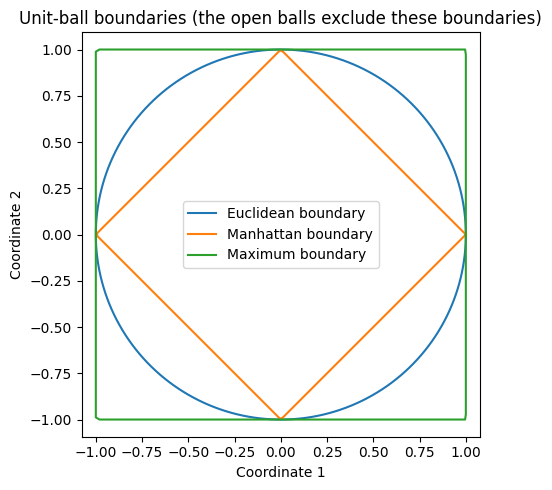

In [4]:
theta = np.linspace(0, 2*np.pi, 400)
x, y = np.cos(theta), np.sin(theta)
plt.figure(figsize=(5, 5))
plt.plot(x, y, label="Euclidean boundary")
plt.plot(x/(abs(x)+abs(y)), y/(abs(x)+abs(y)), label="Manhattan boundary")
plt.plot(x/np.maximum(abs(x),abs(y)), y/np.maximum(abs(x),abs(y)), label="Maximum boundary")
plt.axis("equal"); plt.xlabel("Coordinate 1"); plt.ylabel("Coordinate 2")
plt.title("Unit-ball boundaries (the open balls exclude these boundaries)"); plt.legend()
show_and_save(OUT / "metric_balls.png")

## Real data: changing the geometry by scaling
This is exploratory Iris analysis. A prediction task must fit its scaler on training data, not all observations.

In [5]:
from shape_lab.data import load_iris_data
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
iris = load_iris_data(); X = iris.iloc[:, 1:5].to_numpy()
Z = StandardScaler().fit_transform(X)
query = 100
raw = cdist(X[[query]], X)[0]
scaled = cdist(Z[[query]], Z)[0]
raw[query] = np.inf; scaled[query] = np.inf
raw_ids = np.argsort(raw, kind="stable")[:8]
scaled_ids = np.argsort(scaled, kind="stable")[:8]
print("Query ID:", query)
print("Raw nearest IDs:", raw_ids)
print("Standardized nearest IDs:", scaled_ids)
assert np.allclose(cdist(X, X), cdist(X+17, X+17))
save_json(OUT / "results.json", {"query_id": query, "raw_neighbors": raw_ids,
          "scaled_neighbors": scaled_ids, "overlap": len(set(raw_ids)&set(scaled_ids)),
          "squared_distance_is_metric": False})

Query ID: 100
Raw nearest IDs: [136 144 104 143 140 124 148 120]
Standardized nearest IDs: [136 148 144 115 143 140 124 120]


## Interpretation
A changed neighbor list is evidence that the preprocessing changes this representation. It does not establish that one metric is biologically correct. Explain why labels were excluded.

## Mastery gate
Verify metrics and topology axioms, prove finite discreteness, and distinguish observed points from inferred shape.

A successful Run All is computational evidence, not a learner pass. Complete the lesson’s original exercises before reading `solutions/02_solutions.md`. Record independent work, corrections and a delayed re-test in your learner ledger.

## Sources and conventions
Source IDs: R1, R2, R3, D1, D3; direct links and assignments are in `docs/SOURCES.md`. Core conventions are in `docs/MATHEMATICAL_CONVENTIONS.md`.